# 🩺 Prediksi Penyakit Diabetes — EDA & Preprocessing
## UAS Pembelajaran Mesin | Semester Genap 2025/2026
### Universitas Dian Nuswantoro (UDINUS) Semarang

| | |
|---|---|
| **Kelompok** | Fahmi Fatmawati Azzahra (A11.2024.15831) & Nathaniela Febry Nathasa (A11.2024.15850) |
| **Dataset** | Pima Indians Diabetes Database (NIDDK) |
| **Task** | Binary Classification — Deteksi Penyakit Diabetes |
| **Notebook** | 01 — Exploratory Data Analysis & Preprocessing |

---


## 1. Import Library & Konfigurasi

Mengimpor semua library yang diperlukan untuk EDA dan preprocessing.


In [1]:
import os
import sys
import warnings
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

# Konfigurasi plot
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
FIGDPI = 100

# Konstanta
COLUMNS = [
    'Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
    'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'
]
ZERO_INVALID_COLS = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
RANDOM_STATE = 42

PALETTE = {
    'primary'  : '#2E86AB',
    'secondary': '#A23B72',
    'accent'   : '#F18F01',
    'danger'   : '#C73E1D',
    'success'  : '#27AE60',
}

print("[OK] Library berhasil diimport")
print(f"  NumPy   : {np.__version__}")
print(f"  Pandas  : {pd.__version__}")


[OK] Library berhasil diimport
  NumPy   : 2.5.1
  Pandas  : 3.0.3


---
## 2. Data Acquisition (Soal 1)

### 2.1 Problem Statement

**Domain:** Kesehatan / Medis — Prediksi Penyakit Diabetes

Diabetes mellitus merupakan penyakit kronis yang ditandai oleh kadar glukosa darah tinggi akibat gangguan produksi atau kerja insulin. Menurut IDF Diabetes Atlas 2021, terdapat **537 juta** orang dewasa dengan diabetes di seluruh dunia, diproyeksikan meningkat menjadi **783 juta** pada 2045.

**Tujuan Bisnis/Analisis:**
- Mengembangkan model ML yang mampu memprediksi risiko diabetes berdasarkan data kesehatan dasar
- Mendukung skrining dini untuk mengurangi biaya dan risiko komplikasi
- Mengidentifikasi faktor risiko paling berpengaruh terhadap diabetes

**Metrik Kesuksesan:**
- Accuracy ≥ 75%
- F1-Score ≥ 0.70
- AUC-ROC ≥ 0.80
- Recall ≥ 0.75 (minimisasi false negative)

### 2.2 Sumber Dataset

- **Nama:** Pima Indians Diabetes Database
- **Institusi:** National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)
- **Akses:** UCI Machine Learning Repository, Kaggle
- **URL Kaggle:** https://www.kaggle.com/uciml/pima-indians-diabetes-database
- **URL UCI:** https://archive.ics.uci.edu/ml/datasets/diabetes


In [2]:
# Download dataset jika belum ada
DATA_DIR = Path('../data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
DATASET_PATH = DATA_DIR / 'diabetes.csv'

DATASET_URL = ("https://raw.githubusercontent.com/jbrownlee/"
               "Datasets/master/pima-indians-diabetes.data.csv")

if DATASET_PATH.exists():
    _first = open(DATASET_PATH, encoding='utf-8').readline().strip()
    if _first.startswith('Pregnancies'):
        df_raw = pd.read_csv(DATASET_PATH)
        print(f'[OK] Dataset dimuat dari lokal (header sudah ada): {DATASET_PATH}')
    else:
        df_raw = pd.read_csv(DATASET_PATH, header=None, names=COLUMNS)
        df_raw.to_csv(DATASET_PATH, index=False)
        print(f'[OK] Dataset dimuat & header ditambahkan: {DATASET_PATH}')
else:
    print('-> Mengunduh dataset...')
    urllib.request.urlretrieve(DATASET_URL, DATASET_PATH)
    df_raw = pd.read_csv(DATASET_PATH, header=None, names=COLUMNS)
    df_raw.to_csv(DATASET_PATH, index=False)
    print(f'[OK] Dataset diunduh & disimpan: {DATASET_PATH}')

print(f'\n[STATS] Dataset berhasil dimuat!')
print(f'   Shape: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom')


[OK] Dataset dimuat dari lokal (header sudah ada): ..\data\diabetes.csv

[STATS] Dataset berhasil dimuat!
   Shape: 768 baris x 9 kolom


---
## 3. Statistik Deskriptif Awal (Soal 1 — Keluaran Wajib)


In [3]:
# Preview data
print("=== 5 BARIS PERTAMA ===")
display(df_raw.head())


=== 5 BARIS PERTAMA ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6000,0.6270,50,1
1,1,85,66,29,0,26.6000,0.3510,31,0
2,8,183,64,0,0,23.3000,0.6720,32,1
3,1,89,66,23,94,28.1000,0.1670,21,0
4,0,137,40,35,168,43.1000,2.2880,33,1


In [4]:
# Informasi tipe data
print("=== INFO DATASET ===")
df_raw.info()


=== INFO DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Statistik deskriptif lengkap
print("=== STATISTIK DESKRIPTIF ===")
display(df_raw.describe().T.round(3))


=== STATISTIK DESKRIPTIF ===


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0000,3.8450,3.3700,0.0000,1.0000,3.0000,6.0000,17.0000
Glucose,768.0000,120.8950,31.9730,0.0000,99.0000,117.0000,140.2500,199.0000
BloodPressure,768.0000,69.1050,19.3560,0.0000,62.0000,72.0000,80.0000,122.0000
SkinThickness,768.0000,20.5360,15.9520,0.0000,0.0000,23.0000,32.0000,99.0000
Insulin,768.0000,79.7990,115.2440,0.0000,0.0000,30.5000,127.2500,846.0000
BMI,768.0000,31.9930,7.8840,0.0000,27.3000,32.0000,36.6000,67.1000
DiabetesPedigreeFunction,768.0000,0.4720,0.3310,0.0780,0.2440,0.3720,0.6260,2.4200
Age,768.0000,33.2410,11.7600,21.0000,24.0000,29.0000,41.0000,81.0000
Outcome,768.0000,0.3490,0.4770,0.0000,0.0000,0.0000,1.0000,1.0000


In [6]:
# Distribusi kelas target
print('=== DISTRIBUSI KELAS TARGET ===')
n0 = int((df_raw['Outcome'] == 0).sum())
n1 = int((df_raw['Outcome'] == 1).sum())
print(f'Non-Diabetes (0) : {n0:4d} ({n0/len(df_raw)*100:.1f}%)')
print(f'Diabetes     (1) : {n1:4d} ({n1/len(df_raw)*100:.1f}%)')
print(f'\nTotal           : {len(df_raw)}')
print(f'Rasio imbalance  : {n0/n1:.2f} : 1')


=== DISTRIBUSI KELAS TARGET ===
Non-Diabetes (0) :  500 (65.1%)
Diabetes     (1) :  268 (34.9%)

Total           : 768
Rasio imbalance  : 1.87 : 1


---
## 4. Exploratory Data Analysis (Soal 2)

### 4.1 Analisis Kualitas Data


In [7]:
# === 4.1.1 MISSING VALUES (NaN eksplisit) ===
print("=== MISSING VALUES (NaN) ===")
nan_counts = df_raw.isnull().sum()
print(nan_counts)
print(f"\nTotal NaN: {nan_counts.sum()}")
print("-> Tidak ada NaN eksplisit, tapi ada nilai 0 yang tidak valid secara medis.")


=== MISSING VALUES (NaN) ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total NaN: 0
-> Tidak ada NaN eksplisit, tapi ada nilai 0 yang tidak valid secara medis.


In [8]:
# === 4.1.2 NILAI 0 TIDAK VALID (implicit missing values) ===
print("=== NILAI 0 TIDAK VALID ===")
print(f"{'Kolom':<35} {'Jumlah 0':>10} {'Persen %':>10}")
print("-" * 58)
zero_info = {}
for col in ZERO_INVALID_COLS:
    cnt = (df_raw[col] == 0).sum()
    pct = cnt / len(df_raw) * 100
    zero_info[col] = cnt
    print(f"  {col:<33} {cnt:>10} {pct:>9.1f}%")
print(f"\n-> Kolom Insulin memiliki nilai 0 terbanyak: {zero_info['Insulin']} data ({zero_info['Insulin']/len(df_raw)*100:.1f}%)")


=== NILAI 0 TIDAK VALID ===
Kolom                                 Jumlah 0   Persen %
----------------------------------------------------------
  Glucose                                    5       0.7%
  BloodPressure                             35       4.6%
  SkinThickness                            227      29.6%
  Insulin                                  374      48.7%
  BMI                                       11       1.4%

-> Kolom Insulin memiliki nilai 0 terbanyak: 374 data (48.7%)


In [9]:
# === 4.1.3 DUPLIKAT ===
n_dup = df_raw.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")
if n_dup == 0:
    print("[OK] Dataset bebas duplikat.")


Jumlah baris duplikat: 0
[OK] Dataset bebas duplikat.


In [10]:
# === 4.1.4 OUTLIER (IQR Method) ===
print("=== OUTLIER DETECTION (IQR × 1.5) ===")
print(f"{'Kolom':<35} {'Outlier':>8} {'%':>6} {'Batas Bawah':>12} {'Batas Atas':>12}")
print("-" * 78)
for col in COLUMNS[:-1]:
    q1, q3 = df_raw[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df_raw[col] < lo) | (df_raw[col] > hi)).sum()
    pct = n_out / len(df_raw) * 100
    print(f"  {col:<33} {n_out:>8} {pct:>5.1f}% {lo:>12.2f} {hi:>12.2f}")


=== OUTLIER DETECTION (IQR × 1.5) ===
Kolom                                Outlier      %  Batas Bawah   Batas Atas
------------------------------------------------------------------------------
  Pregnancies                              4   0.5%        -6.50        13.50
  Glucose                                  5   0.7%        37.12       202.12
  BloodPressure                           45   5.9%        35.00       107.00
  SkinThickness                            1   0.1%       -48.00        80.00
  Insulin                                 34   4.4%      -190.88       318.12
  BMI                                     19   2.5%        13.35        50.55
  DiabetesPedigreeFunction                29   3.8%        -0.33         1.20
  Age                                      9   1.2%        -1.50        66.50


### 4.2 Visualisasi EDA — Insight 1: Distribusi Kelas Target


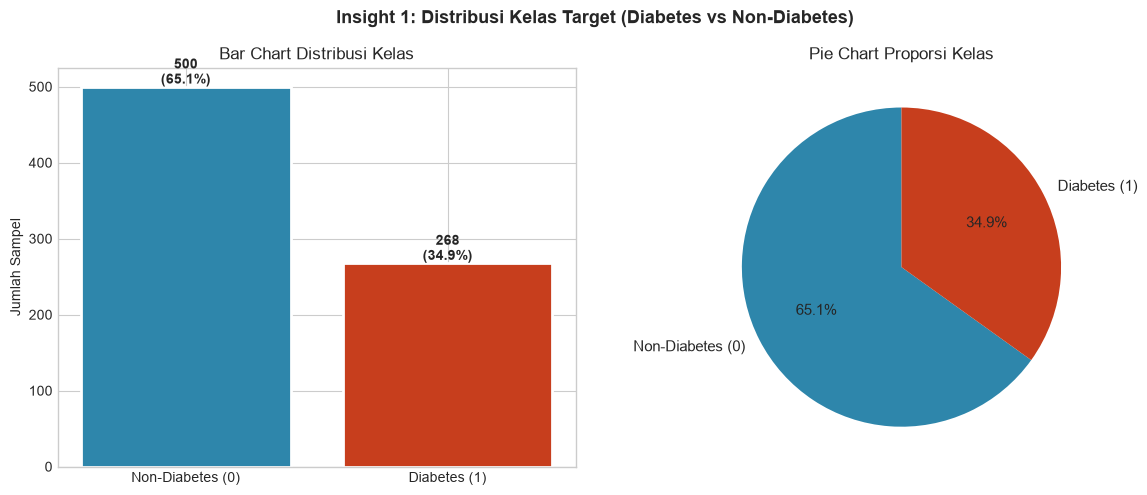

[WARNING]  Dataset TIDAK SEIMBANG: rasio 65:35. Perlu class_weight='balanced' pada model.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Insight 1: Distribusi Kelas Target (Diabetes vs Non-Diabetes)',
             fontsize=13, fontweight='bold')

cnts = df_raw['Outcome'].value_counts()
clrs = [PALETTE['primary'], PALETTE['danger']]
lbls = ['Non-Diabetes (0)', 'Diabetes (1)']

# Bar
axes[0].bar(lbls, [cnts[0], cnts[1]], color=clrs, edgecolor='white', linewidth=2)
for i, v in enumerate([cnts[0], cnts[1]]):
    axes[0].text(i, v+4, f'{v}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_title('Bar Chart Distribusi Kelas')

# Pie
axes[1].pie([cnts[0], cnts[1]], labels=lbls, colors=clrs,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':11})
axes[1].set_title('Pie Chart Proporsi Kelas')

plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()
print("[WARNING]  Dataset TIDAK SEIMBANG: rasio 65:35. Perlu class_weight='balanced' pada model.")


### 4.3 Visualisasi — Insight 2: Distribusi Fitur per Kelas


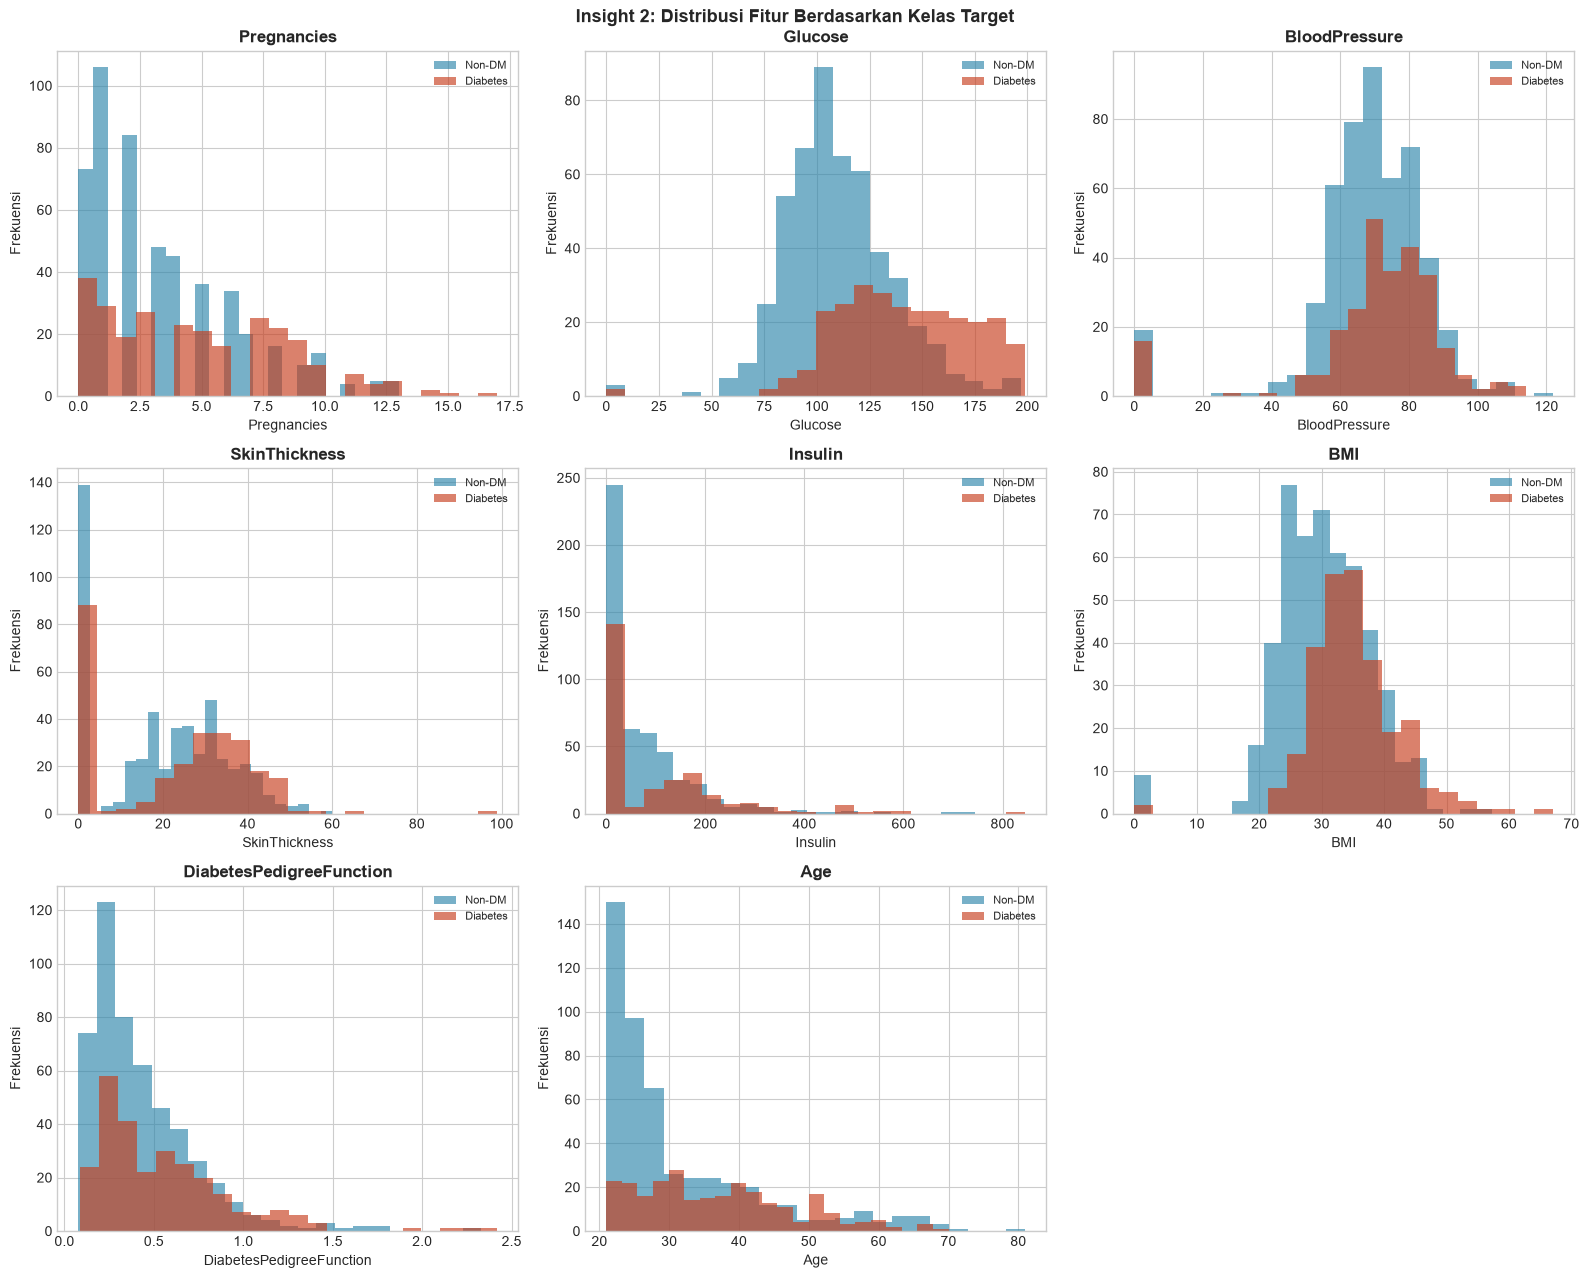

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 13))
fig.suptitle('Insight 2: Distribusi Fitur Berdasarkan Kelas Target',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(COLUMNS[:-1]):
    ax = axes_flat[i]
    for ov, lbl, clr in [(0, 'Non-DM', PALETTE['primary']),
                          (1, 'Diabetes', PALETTE['danger'])]:
        data = df_raw[df_raw['Outcome'] == ov][col]
        ax.hist(data, bins=22, alpha=0.65, label=lbl, color=clr, edgecolor='none')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=8)

for j in range(i+1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/figures/02_feature_distributions.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


### 4.4 Visualisasi — Insight 3: Korelasi Antar Fitur


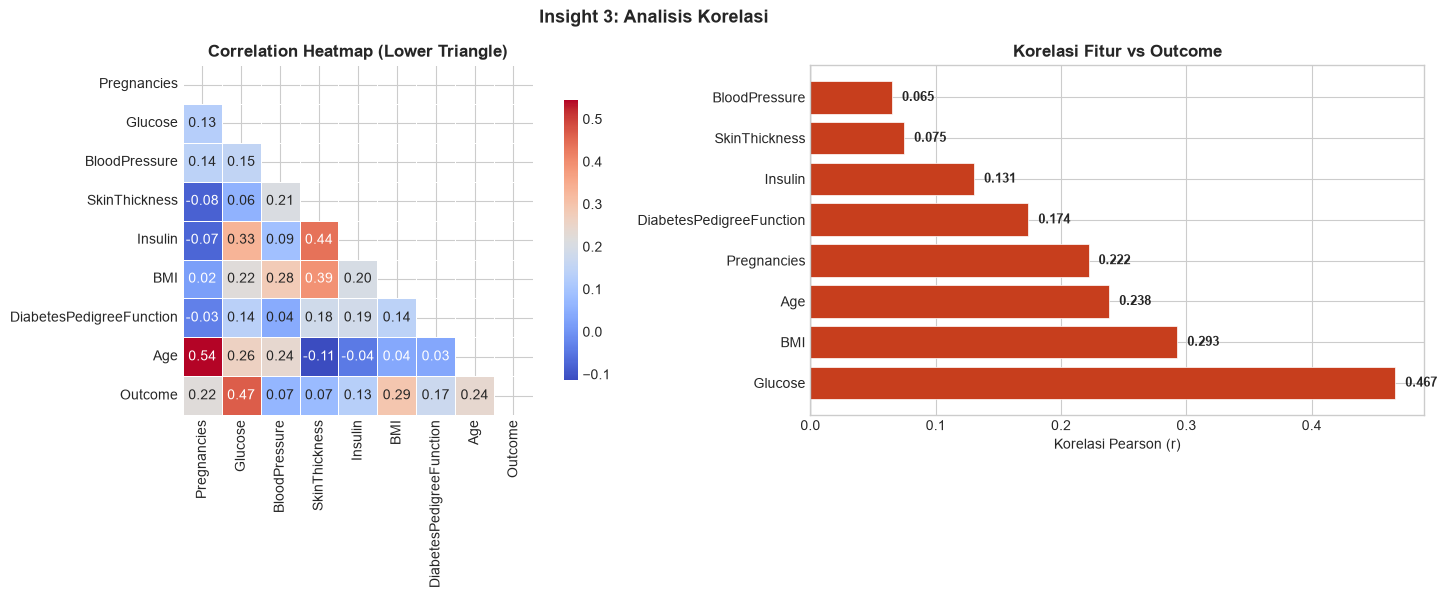


Korelasi Fitur dengan Outcome (urutan):
  Glucose                       : +0.4666
  BMI                           : +0.2927
  Age                           : +0.2384
  Pregnancies                   : +0.2219
  DiabetesPedigreeFunction      : +0.1738
  Insulin                       : +0.1305
  SkinThickness                 : +0.0748
  BloodPressure                 : +0.0651


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Insight 3: Analisis Korelasi', fontsize=13, fontweight='bold')

# Heatmap
corr = df_raw.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=axes[0], linewidths=0.5, square=True, cbar_kws={'shrink':.8})
axes[0].set_title('Correlation Heatmap (Lower Triangle)', fontweight='bold')

# Korelasi vs Outcome
tc = corr['Outcome'].drop('Outcome').sort_values(ascending=False)
clrs_bar = [PALETTE['danger'] if v > 0 else PALETTE['primary'] for v in tc.values]
axes[1].barh(tc.index, tc.values, color=clrs_bar, edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Korelasi Pearson (r)')
axes[1].set_title('Korelasi Fitur vs Outcome', fontweight='bold')

for i, (name, val) in enumerate(tc.items()):
    axes[1].text(val + (0.008 if val >= 0 else -0.008), i,
                f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right',
                fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_correlation_heatmap.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()

print("\nKorelasi Fitur dengan Outcome (urutan):")
for feat, val in tc.items():
    print(f"  {feat:<30}: {val:+.4f}")


### 4.5 Visualisasi — Insight 4: Deteksi Outlier (Boxplots)


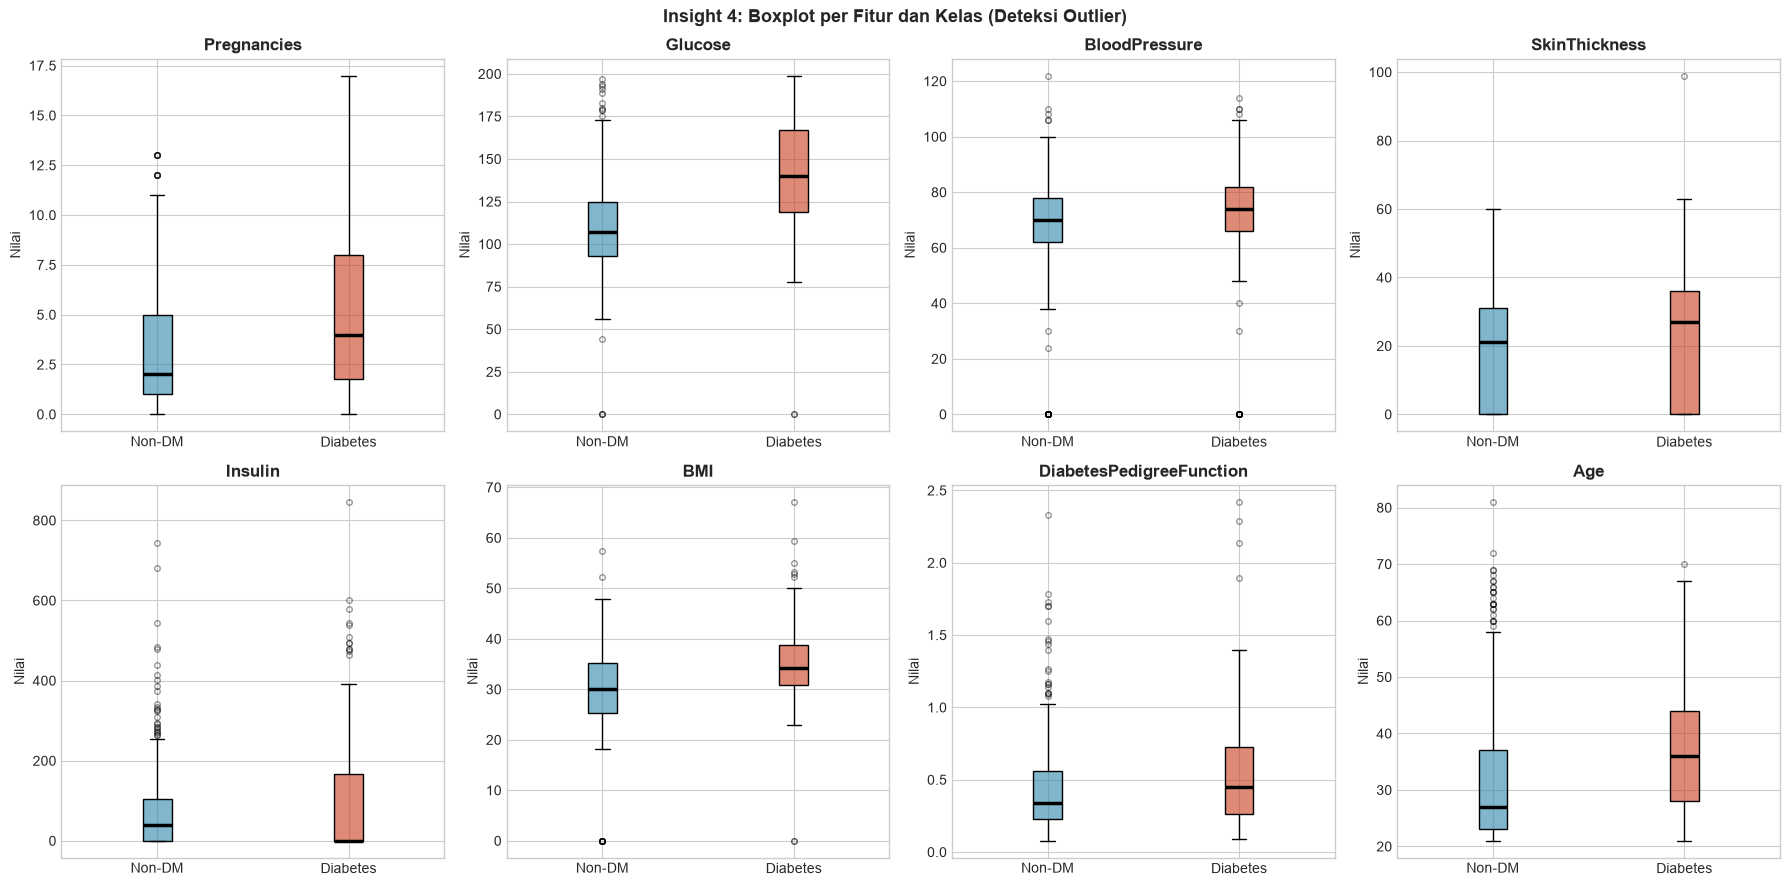

In [14]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Insight 4: Boxplot per Fitur dan Kelas (Deteksi Outlier)',
             fontsize=13, fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(COLUMNS[:-1]):
    ax = axes_flat[i]
    data0 = df_raw[df_raw['Outcome'] == 0][col].dropna().values
    data1 = df_raw[df_raw['Outcome'] == 1][col].dropna().values
    bp = ax.boxplot([data0, data1], tick_labels=['Non-DM','Diabetes'],
                    patch_artist=True, medianprops=dict(color='black', lw=2.5),
                    flierprops=dict(marker='o', markersize=4, alpha=0.4))
    bp['boxes'][0].set_facecolor(PALETTE['primary'] + '99')
    bp['boxes'][1].set_facecolor(PALETTE['danger']  + '99')
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Nilai')

plt.tight_layout()
plt.savefig('../reports/figures/04_boxplots.png', dpi=FIGDPI, bbox_inches='tight')
plt.show()


### 4.6 Visualisasi — Insight 5: Nilai 0 Tidak Valid


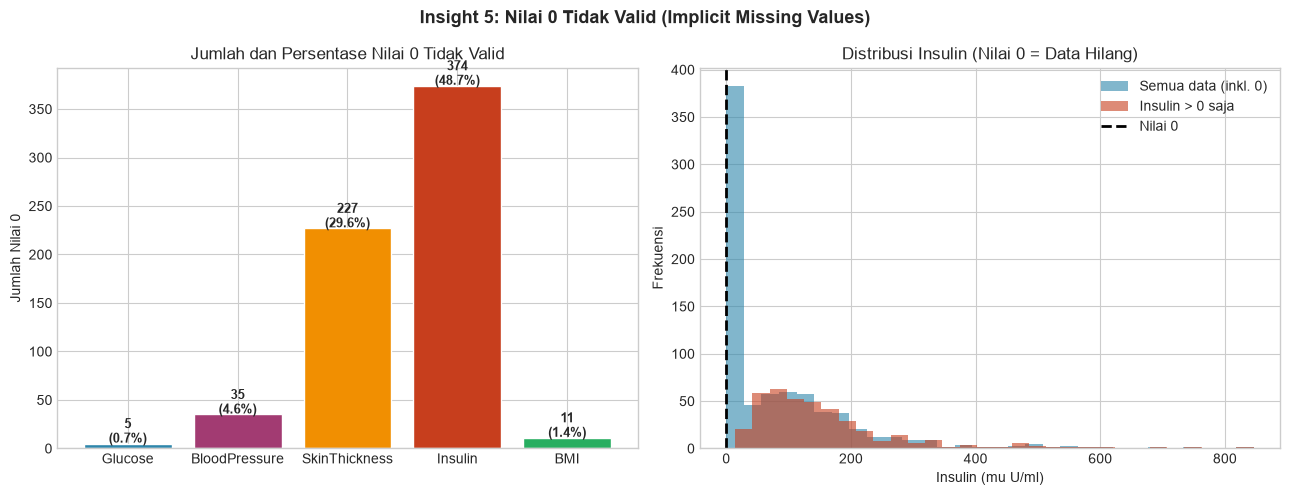

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Insight 5: Nilai 0 Tidak Valid (Implicit Missing Values)',
             fontsize=13, fontweight='bold')

# Bar chart jumlah nilai 0
zero_counts = {col: (df_raw[col] == 0).sum() for col in ZERO_INVALID_COLS}
pct_vals = [v/len(df_raw)*100 for v in zero_counts.values()]
bar_clrs = [PALETTE['primary'], PALETTE['secondary'], PALETTE['accent'],
            PALETTE['danger'], PALETTE['success']]

bars = axes[0].bar(zero_counts.keys(), zero_counts.values(), color=bar_clrs, edgecolor='white')
for bar, val, pct in zip(bars, zero_counts.values(), pct_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylabel('Jumlah Nilai 0')
axes[0].set_title('Jumlah dan Persentase Nilai 0 Tidak Valid')

# Distribusi insulin sebelum dan sesudah filter 0
axes[1].hist(df_raw['Insulin'], bins=30, alpha=0.6, color=PALETTE['primary'],
             label=f'Semua data (inkl. 0)', edgecolor='none')
axes[1].hist(df_raw[df_raw['Insulin'] > 0]['Insulin'], bins=30, alpha=0.6,
             color=PALETTE['danger'], label='Insulin > 0 saja', edgecolor='none')
axes[1].axvline(0, color='black', linewidth=2, linestyle='--', label='Nilai 0')
axes[1].set_xlabel('Insulin (mu U/ml)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Insulin (Nilai 0 = Data Hilang)')
axes[1].legend()

plt.tight_layout()
plt.show()


---
## 5. Preprocessing (Soal 2)

### 5.1 Ganti Nilai 0 Tidak Valid -> NaN


In [16]:
df = df_raw.copy()

# Ganti nilai 0 yang tidak valid secara medis dengan NaN
for col in ZERO_INVALID_COLS:
    sebelum = (df[col] == 0).sum()
    df[col] = df[col].replace(0, np.nan)
    print(f"  {col:<30}: {sebelum} nilai 0 -> NaN")

print(f"\nTotal NaN setelah penggantian: {df.isnull().sum().sum()}")


  Glucose                       : 5 nilai 0 -> NaN
  BloodPressure                 : 35 nilai 0 -> NaN
  SkinThickness                 : 227 nilai 0 -> NaN
  Insulin                       : 374 nilai 0 -> NaN
  BMI                           : 11 nilai 0 -> NaN

Total NaN setelah penggantian: 652


### 5.2 Imputasi Nilai Hilang (Stratified Median Imputation)

Imputasi menggunakan **median per kelas** (bukan median global) untuk mempertahankan
distribusi statistik dalam setiap kelompok.


In [17]:
print("=== STRATIFIED MEDIAN IMPUTATION ===")
print(f"{'Kolom':<30} {'Median(0)':>10} {'Median(1)':>10} {'Jumlah Diimputasi':>18}")
print("-" * 70)

for col in ZERO_INVALID_COLS:
    n_nan = df[col].isna().sum()
    for outcome_val in [0, 1]:
        mask_nan   = (df['Outcome'] == outcome_val) & df[col].isna()
        mask_valid = (df['Outcome'] == outcome_val) & df[col].notna()
        med = df.loc[mask_valid, col].median()
        df.loc[mask_nan, col] = med
    
    med0 = df[df['Outcome']==0][col].median()
    med1 = df[df['Outcome']==1][col].median()
    print(f"  {col:<28} {med0:>10.2f} {med1:>10.2f} {n_nan:>18}")

print(f"\nNaN setelah imputasi: {df.isnull().sum().sum()}")
print("[OK] Semua nilai berhasil diimputasi!")


=== STRATIFIED MEDIAN IMPUTATION ===
Kolom                           Median(0)  Median(1)  Jumlah Diimputasi
----------------------------------------------------------------------
  Glucose                          107.00     140.00                  5
  BloodPressure                     70.00      74.50                 35
  SkinThickness                     27.00      32.00                227
  Insulin                          102.50     169.50                374
  BMI                               30.10      34.30                 11

NaN setelah imputasi: 0
[OK] Semua nilai berhasil diimputasi!


### 5.3 Feature Engineering

Menambahkan fitur turunan yang relevan secara domain medis.


In [18]:
# BMI Category: 0=Underweight(<18.5), 1=Normal(18.5-24.9), 2=Overweight(25-29.9), 3=Obese(≥30)
df['BMI_Category'] = pd.cut(df['BMI'],
                             bins=[0, 18.5, 25.0, 30.0, float('inf')],
                             labels=[0, 1, 2, 3]).astype(float)

# Glucose Category: 0=Normal(<100), 1=Pre-Diabetes(100-125), 2=Diabetes(≥126)
df['Glucose_Category'] = pd.cut(df['Glucose'],
                                  bins=[0, 99.9, 125.9, float('inf')],
                                  labels=[0, 1, 2]).astype(float)

# Age Group: 0=Young(<35), 1=Middle(35-50), 2=Senior(>50)
df['Age_Group'] = pd.cut(df['Age'],
                          bins=[0, 34.9, 49.9, float('inf')],
                          labels=[0, 1, 2]).astype(float)

# Insulin-Glucose Ratio
df['Insulin_Glucose_Ratio'] = df['Insulin'] / (df['Glucose'] + 1.0)

feat_eng = ['BMI_Category', 'Glucose_Category', 'Age_Group', 'Insulin_Glucose_Ratio']
print("Fitur baru yang ditambahkan:")
for f in feat_eng:
    print(f"  + {f}")

print(f"\nTotal fitur sekarang: {df.shape[1]-1} (dari {len(COLUMNS)-1} + {len(feat_eng)} baru)")
display(df[feat_eng + ['Outcome']].head(10))


Fitur baru yang ditambahkan:
  + BMI_Category
  + Glucose_Category
  + Age_Group
  + Insulin_Glucose_Ratio

Total fitur sekarang: 12 (dari 8 + 4 baru)


,BMI_Category,Glucose_Category,Age_Group,Insulin_Glucose_Ratio,Outcome
0,3.0000,2.0000,2.0000,1.1376,1
1,2.0000,0.0000,0.0000,1.1919,0
2,1.0000,2.0000,0.0000,0.9212,1
3,2.0000,0.0000,0.0000,1.0444,0
4,3.0000,2.0000,0.0000,1.2174,1
5,2.0000,1.0000,0.0000,0.8761,0
6,3.0000,0.0000,0.0000,1.1139,1
7,3.0000,1.0000,0.0000,0.8836,0
8,3.0000,2.0000,2.0000,2.7424,1
9,3.0000,1.0000,2.0000,1.3452,1


### 5.4 Train / Validation / Test Split (70% / 15% / 15%)


In [19]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df.columns if c != 'Outcome']
X = df[feature_cols].values
y = df['Outcome'].values

# Split pertama: TV (85%) vs Test (15%)
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE, stratify=y
)

# Split kedua: Train (70% total) vs Val (15% total)
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.1765, random_state=RANDOM_STATE, stratify=y_tv
)

print("=== PEMBAGIAN DATASET ===")
print(f"  Training set  : {len(X_train):4d} sampel ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val):4d} sampel ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set      : {len(X_test):4d} sampel ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Total         : {len(X):4d} sampel")
print()
print("Distribusi kelas di setiap split:")
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  {name}: Non-DM={sum(ys==0)} | Diabetes={sum(ys==1)}")


=== PEMBAGIAN DATASET ===
  Training set  :  536 sampel (69.8%)
  Validation set:  116 sampel (15.1%)
  Test set      :  116 sampel (15.1%)
  Total         :  768 sampel

Distribusi kelas di setiap split:
  Train: Non-DM=349 | Diabetes=187
  Val: Non-DM=75 | Diabetes=41
  Test: Non-DM=76 | Diabetes=40


### 5.5 Feature Scaling (StandardScaler)

StandardScaler menstandardisasi fitur dengan mengurangi mean dan membagi std deviation.
**Penting:** Scaler di-fit HANYA pada training data untuk mencegah data leakage.


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # Fit + Transform pada training
X_val_sc   = scaler.transform(X_val)          # Hanya Transform (no fit)
X_test_sc  = scaler.transform(X_test)         # Hanya Transform (no fit)

print("StandardScaler berhasil diterapkan!")
print()
print("Statistik sebelum scaling (train):")
df_train_pre = pd.DataFrame(X_train, columns=feature_cols)
print(df_train_pre.describe().round(3).T[['mean','std','min','max']])
print()
print("Statistik setelah scaling (train):")
df_train_sc = pd.DataFrame(X_train_sc, columns=feature_cols)
print(df_train_sc.describe().round(3).T[['mean','std','min','max']])


StandardScaler berhasil diterapkan!

Statistik sebelum scaling (train):
                             mean     std     min      max
Pregnancies                3.8340  3.3860  0.0000  17.0000
Glucose                  121.5150 29.5450 56.0000 199.0000
BloodPressure             71.8290 12.3490 24.0000 122.0000
SkinThickness             28.8190  9.1940  7.0000  99.0000
Insulin                  139.1620 81.5920 15.0000 744.0000
BMI                       32.2120  6.6900 18.2000  67.1000
DiabetesPedigreeFunction   0.4690  0.3250  0.0840   2.3290
Age                       33.5390 11.8270 21.0000  72.0000
BMI_Category               2.4660  0.7380  0.0000   3.0000
Glucose_Category           1.1440  0.7850  0.0000   2.0000
Age_Group                  0.4930  0.7020  0.0000   2.0000
Insulin_Glucose_Ratio      1.1220  0.5090  0.1730   3.7580

Statistik setelah scaling (train):
                            mean    std     min    max
Pregnancies              -0.0000 1.0010 -1.1330 3.8930
Glucose        

---
## 6. Ringkasan Preprocessing

| Langkah | Teknik | Justifikasi |
|---------|--------|-------------|
| Deteksi Missing Values | Nilai 0 pada kolom medis | 0 tidak mungkin secara medis untuk Glucose, BMI, dll. |
| Imputasi | Median per kelas (stratified) | Mempertahankan distribusi per kelas, robust terhadap outlier |
| Feature Engineering | BMI/Glucose/Age categories + Ratio | Informasi domain medis tambahan |
| Train/Val/Test Split | 70/15/15 stratified | Distribusi kelas terjaga di semua split |
| Feature Scaling | StandardScaler (fit on train only) | Mencegah data leakage |

---

## 7. Ringkasan 5 Key Insights

1. **🩸 Glukosa = Prediktor Terkuat** — Korelasi tertinggi dengan Outcome (r ≈ 0.47)
2. **⚖️ BMI Tinggi -> Risiko Tinggi** — Penderita diabetes rata-rata BMI jauh lebih tinggi
3. **🎂 Usia Berpengaruh** — Penderita diabetes rata-rata lebih tua
4. **💉 Data Insulin Banyak Hilang** — ~48% data Insulin bernilai 0 (tidak valid)
5. **⚖️ Class Imbalance** — 65% Non-DM vs 35% DM -> perlu penanganan khusus

---

*Notebook ini merupakan bagian dari Soal 2 (EDA & Preprocessing) UAS Pembelajaran Mesin.*  
*Kelompok: Fahmi Fatmawati Azzahra (A11.2024.15831) & Nathaniela Febry Nathasa (A11.2024.15850)*
